---
date: "2026-08-07"
date-modified: last-modified
format:
  html:
    toc: true
---


# Problem Set: Linear Programs

## Problem 1: The Diet Program

**Problem Statement:**
A classic application of linear programming is the "Diet Problem." Suppose you must design a daily diet using a selection of available foods to meet strict nutritional requirements at the absolute lowest cost.

Consider a simplified scenario with two food items and two essential nutrients:

- **Food 1 (Oats):** Costs $\$1.50$ per serving. Each serving contains $3$ units of Protein and $2$ units of Carbohydrates.
- **Food 2 (Eggs):** Costs $\$2.00$ per serving. Each serving contains $4$ units of Protein and $1$ unit of Carbohydrates.

The minimum daily nutritional requirements are:
- At least $12$ units of Protein.
- At least $6$ units of Carbohydrates.

Formulate this scenario mathematically as a linear program, and find the optimal amount of each food to consume to minimize total cost.

::: {.callout-tip collapse="true"}
## Solution

**1. Mathematical Formulation:**
Let $x_1$ be the number of servings of Oats, and $x_2$ be the number of servings of Eggs.
Our objective is to minimize the total cost of the diet:
$$
\text{Minimize} \quad Z = 1.5 x_1 + 2.0 x_2
$$
Subject to the nutritional constraints:
$$
\begin{aligned}
3 x_1 + 4 x_2 &\ge 12 \quad \text{(Protein requirement)} \\
2 x_1 + 1 x_2 &\ge 6 \quad \text{(Carbohydrates requirement)} \\
x_1, x_2 &\ge 0 \quad \text{(Non-negativity)}
\end{aligned}
$$

**2. Conversion to Standard Inequality Form:**
Standard linear programming solvers typically expect constraints in the "less-than-or-equal-to" form ($A x \le b$). We multiply the nutritional requirements by $-1$:
$$
\begin{aligned}
-3 x_1 - 4 x_2 &\le -12 \\
-2 x_1 - 1 x_2 &\le -6
\end{aligned}
$$

**3. Python Implementation & Solution:**
We can solve this linear program exactly using `scipy.optimize.linprog`.
(See the executed code cell below for the computational derivation).

The optimal quantities are:

- $x_1 = 2.4$ servings of Oats
- $x_2 = 1.2$ servings of Eggs
- Total Minimum Cost = $\$6.00$
:::

=== Diet Program Optimization Results ===
Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal Servings of Oats (x1): 2.40
Optimal Servings of Eggs (x2): 1.20
Minimum Total Cost: $6.00


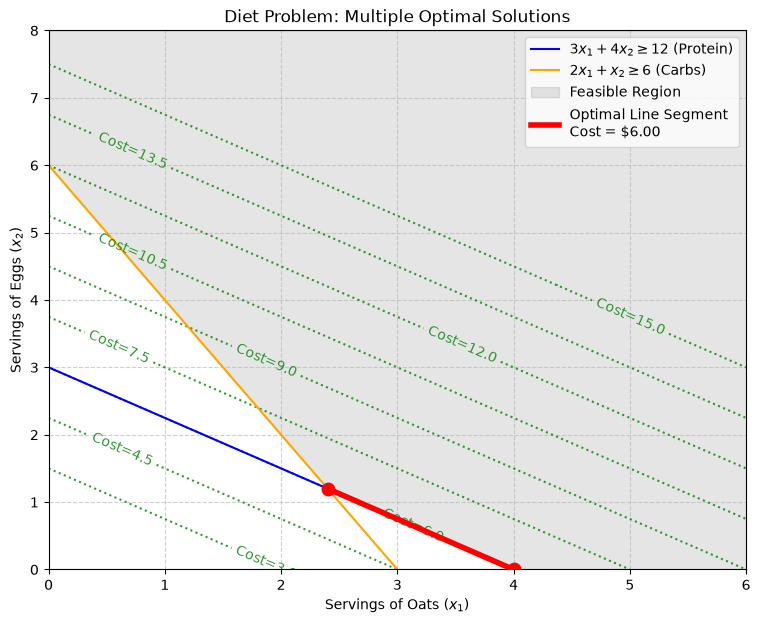

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Objective function coefficients (minimize cost)
c = np.array([1.5, 2.0])

# Inequality constraints matrix (A_ub * x <= b_ub)
A_ub = np.array([
    [-3, -4],  # Protein constraint (multiplied by -1)
    [-2, -1],  # Carbohydrates constraint (multiplied by -1)
])

# Inequality constraints vector
b_ub = np.array([-12, -6])

# Variable bounds (x1 >= 0, x2 >= 0)
bounds = [(0, None), (0, None)]

# Solve the linear program using the HiGHS method
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print("=== Diet Program Optimization Results ===")
if result.success:
    print(f"Status: {result.message}")
    print(f"Optimal Servings of Oats (x1): {result.x[0]:.2f}")
    print(f"Optimal Servings of Eggs (x2): {result.x[1]:.2f}")
    print(f"Minimum Total Cost: ${result.fun:.2f}")
    
    # ==========================================
    # PLOTTING THE FEASIBLE REGION AND SOLUTION
    # ==========================================
    
    # 1. Define the range for x1 (Servings of Oats)
    x1_vals = np.linspace(0, 6, 400)
    
    # 2. Calculate x2 values for the constraint boundary lines
    x2_c1 = (12 - 3 * x1_vals) / 4
    x2_c2 = 6 - 2 * x1_vals
    
    # 3. Determine the lower boundary of the feasible region
    x2_lower_bound = np.maximum(x2_c1, x2_c2)
    x2_lower_bound = np.maximum(x2_lower_bound, 0)
    
    # 4. Set up the plot
    plt.figure(figsize=(9, 7))
    
    # --- OBJECTIVE FUNCTION CONTOURS ---
    X1, X2 = np.meshgrid(np.linspace(0, 6, 200), np.linspace(0, 8, 200))
    Z = c[0] * X1 + c[1] * X2
    
    levels = np.arange(3.0, 16.0, 1.5)
    contours = plt.contour(X1, X2, Z, levels=levels, colors='green', linestyles='dotted', alpha=0.8)
    plt.clabel(contours, inline=True, fontsize=10, fmt='Cost=%.1f')
    
    # Plot the constraint lines
    plt.plot(x1_vals, x2_c1, label=r'$3x_1 + 4x_2 \geq 12$ (Protein)', color='blue')
    plt.plot(x1_vals, x2_c2, label=r'$2x_1 + x_2 \geq 6$ (Carbs)', color='orange')
    
    # Shade the feasible region
    plt.fill_between(x1_vals, x2_lower_bound, 8, where=(x1_vals >= 0), 
                     color='gray', alpha=0.2, label='Feasible Region')
    
    # --- NEW: PLOT THE OPTIMAL LINE SEGMENT ---
    # The segment runs from the intersection (2.4, 1.2) down to the x-axis intercept (4.0, 0)
    plt.plot([2.4, 4.0], [1.2, 0.0], color='red', linewidth=4, zorder=5, 
             label='Optimal Line Segment\nCost = $6.00')
    
    # Add dots at the corners to highlight the bounds of the optimal segment
    plt.scatter([2.4, 4.0], [1.2, 0.0], color='red', s=80, zorder=6)
    # ------------------------------------------
    
    # 6. Formatting
    plt.xlim(0, 6)
    plt.ylim(0, 8)
    plt.xlabel('Servings of Oats ($x_1$)')
    plt.ylabel('Servings of Eggs ($x_2$)')
    plt.title('Diet Problem: Multiple Optimal Solutions')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Show the plot
    plt.show()
else:
    print(f"Status: Optimization Failed - {result.message}")

> **References & Acknowledgments:**
> The Diet Problem is a foundational linear programming example, originally formulated by George Stigler in 1945.